## Question 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (columns: x1, x2, x3, y1, y2, y3)
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]   # x1, x2, x3
Y_cols = D[:, 3:]   # y1, y2, y3

print("Shape of dataset:", D.shape)
print("First 5 rows:\n", D[:5])

Shape of dataset: (100, 6)
First 5 rows:
 [[ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
    3.69171161]
 [ -5.5403588   -5.0031803   -3.99259187 -11.00772693  -3.98562503
    4.90000402]
 [ -4.98212753  -4.58449362  -4.33122591 -11.69731474  -3.58927699
    5.04686274]
 [ -4.49570614  -5.06413838  -4.78201809 -11.97801037  -3.59707103
    4.63593624]
 [ -4.44215386  -4.41137023  -4.5675092  -12.41495176  -2.79950409
    4.73969871]]


### (a) Total Least Squares on the first line (x1, y1)

In [5]:
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]
X = np.hstack((x1.reshape(-1, 1), y1.reshape(-1, 1)))
mean_X = np.mean(X, axis=0)
U = X - mean_X
_, _, Vt = np.linalg.svd(U.T @ U)
a, b = Vt[-1, 0], Vt[-1, 1]
d = a * mean_X[0] + b * mean_X[1]
m_tls = -a / b
c_tls = d / b

print(f"Implicit form  : {a:.4f} * x + {b:.4f} * y = {d:.4f}")
print(f"Slope (m)      : {m_tls:.4f}")
print(f"Intercept (c)  : {c_tls:.4f}")
print(f"Equation       : y = {m_tls:.4f} x + {c_tls:.4f}")

Implicit form  : -0.7736 * x + 0.6337 * y = -3.7942
Slope (m)      : 1.2207
Intercept (c)  : -5.9872
Equation       : y = 1.2207 x + -5.9872


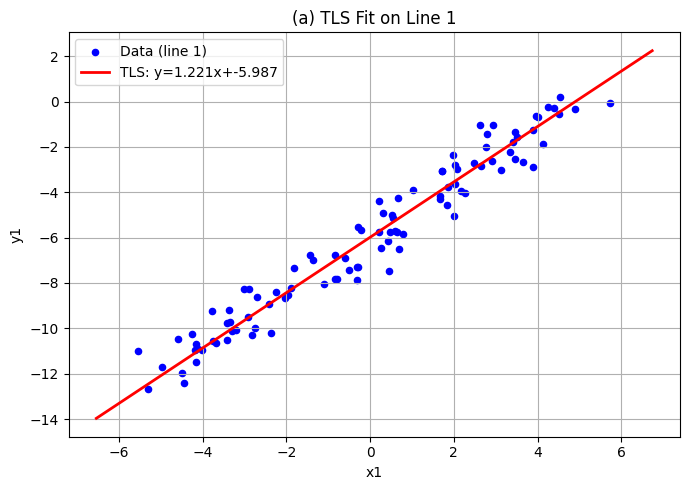

In [6]:
# Plot the (x1, y1) data points and the TLS-fitted line
x_line = np.linspace(x1.min() - 1, x1.max() + 1, 100)
y_line = m_tls * x_line + c_tls

plt.figure(figsize=(7, 5))
plt.scatter(x1, y1, color='blue', s=20, label='Data (line 1)')
plt.plot(x_line, y_line, color='red', linewidth=2,
         label=f'TLS: y={m_tls:.3f}x+{c_tls:.3f}')
plt.xlabel('x1'); plt.ylabel('y1')
plt.title('(a) TLS Fit on Line 1')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

Total Least Squares fits a line by minimising the perpendicular distances from all points to the line, rather than just the vertical errors. This makes it suitable here because both `x1` and `y1` contain noise.

The fitted line for `(x1, y1)` is expressed in two forms:
- **Normal form:** `-0.7736 * x + 0.6337 * y = -3.7942` (where `a² + b² = 1`)
- **Slope-intercept form:** `y = 1.2207 x − 5.9872`

The normal vector `(a, b)` was obtained as the last right singular vector from SVD of the centred data scatter matrix, which points in the direction of minimum variance — i.e., perpendicular to the line.

### (b) RANSAC to find all three lines from the combined point set

In [7]:
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
points = np.column_stack((X_all, Y_all))
print("Total number of points:", points.shape[0])

Total number of points: 300


In [8]:
def fit_line_tls(pts):
    mean_p = np.mean(pts, axis=0)
    U = pts - mean_p
    _, _, Vt = np.linalg.svd(U.T @ U)
    a, b = Vt[-1, 0], Vt[-1, 1]
    d = a * mean_p[0] + b * mean_p[1]
    return a, b, d

def perp_distance(pts, a, b, d):
    return np.abs(a * pts[:, 0] + b * pts[:, 1] - d)

def ransac_line(pts, t=0.5, N=2000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    best_inliers = np.zeros(len(pts), dtype=bool)
    best_count = 0
    n = len(pts)
    for _ in range(N):
        idx = rng.choice(n, size=2, replace=False)
        p1, p2 = pts[idx[0]], pts[idx[1]]
        # Line through 2 points: normal is perpendicular to (p2 - p1)
        dx, dy = p2 - p1
        norm = np.hypot(dx, dy)
        if norm < 1e-9:
            continue
        a = -dy / norm
        b =  dx / norm
        d = a * p1[0] + b * p1[1]
        dists = perp_distance(pts, a, b, d)
        inliers = dists < t
        count = inliers.sum()
        if count > best_count:
            best_count = count
            best_inliers = inliers
    a, b, d = fit_line_tls(pts[best_inliers])
    final_inliers = perp_distance(pts, a, b, d) < t
    return a, b, d, final_inliers

In [9]:
remaining_mask = np.ones(len(points), dtype=bool)  # tracks which points are still active
lines_found = []      # list of (a, b, d)
inlier_groups = []    # list of point arrays (the consensus sets)
rng = np.random.default_rng(42)
for i in range(3):
    active_pts = points[remaining_mask]
    a, b, d, inliers_local = ransac_line(active_pts, t=0.5, N=2000, rng=rng)
    active_idx = np.where(remaining_mask)[0]
    global_inlier_idx = active_idx[inliers_local]
    lines_found.append((a, b, d))
    inlier_groups.append(points[global_inlier_idx])
    remaining_mask[global_inlier_idx] = False
    m = -a / b
    c = d / b
    print(f"Line {i+1}: a={a:+.4f}, b={b:+.4f}, d={d:+.4f}  =>  y = {m:+.4f} x + {c:+.4f}   (inliers: {inliers_local.sum()})")

Line 1: a=+0.4137, b=+0.9104, d=+1.9003  =>  y = -0.4544 x + +2.0874   (inliers: 80)
Line 2: a=-0.7889, b=+0.6145, d=-3.6833  =>  y = +1.2838 x + -5.9941   (inliers: 65)
Line 3: a=-0.7395, b=+0.6731, d=+0.8414  =>  y = +1.0987 x + +1.2500   (inliers: 66)


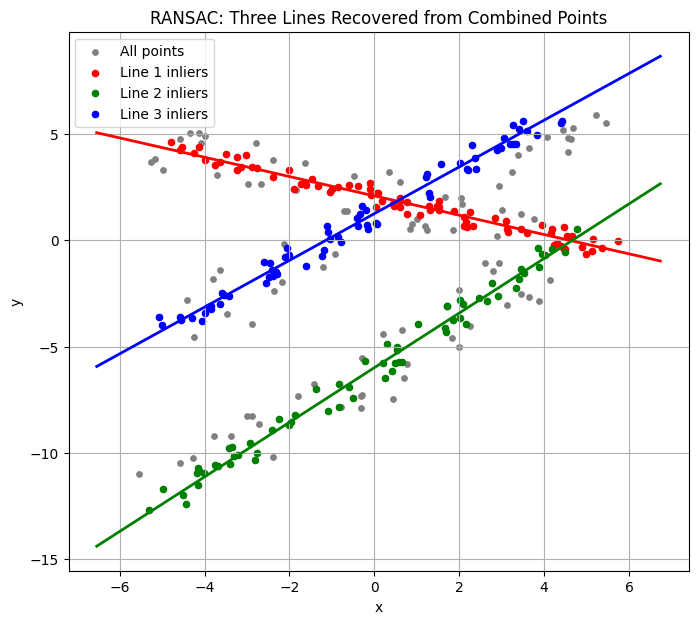

In [10]:
colors = ['red', 'green', 'blue']
plt.figure(figsize=(8, 7))
plt.scatter(points[:, 0], points[:, 1], color='gray', s=15, label='All points')
x_range = np.linspace(points[:, 0].min() - 1, points[:, 0].max() + 1, 100)
for i, ((a, b, d), inliers) in enumerate(zip(lines_found, inlier_groups)):
    plt.scatter(inliers[:, 0], inliers[:, 1], color=colors[i], s=20, label=f'Line {i+1} inliers')
    m = -a / b
    c = d / b
    plt.plot(x_range, m * x_range + c, color=colors[i], linewidth=2)
plt.xlabel('x'); plt.ylabel('y')
plt.title('RANSAC: Three Lines Recovered from Combined Points')
plt.legend(); plt.grid(True)
plt.show()

RANSAC samples two points at a time, fits a candidate line, and counts the inliers within a perpendicular distance of `t = 0.5`, keeping the model with the largest consensus. The line is then refined using TLS on those inliers. After the first line is found, its inliers are masked out and the process is repeated to recover the second and third lines from the remaining points. With `N = 2000` iterations, the three lines are recovered reliably.

## Question 2

Image size: 1024 x 1024 pixels
Two largest circles (cx, cy, r):
  center=(730, 506), radius=190 px
  center=(290, 508), radius=189 px

Average diameter on sensor : 379.0 px = 0.8338 mm
Real earring diameter      : 75.04 mm  (~7.50 cm)


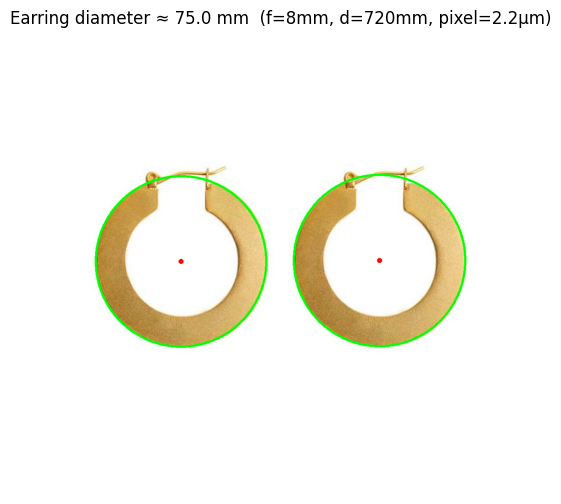

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f_mm = 8.0                 # Focal length (mm)
d_mm = 720.0               # Distance from lens to the earring plane (mm)
pixel_size_mm = 2.2e-3     # 2.2 µm = 0.0022 mm

img = cv.imread("earrings.jpg")
img_rgb  = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray     = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
H, W = gray.shape
print(f"Image size: {W} x {H} pixels")

# ---------- Pre-process: median + Gaussian----------
gray_blur = cv.medianBlur(gray, 5)
gray_blur = cv.GaussianBlur(gray_blur, (5, 5), 2)

# ---------- Hough Circle Transform with a wide radius search ----------
circles = cv.HoughCircles(gray_blur, cv.HOUGH_GRADIENT, dp=1, minDist=100,
                          param1=100, param2=30, minRadius=50, maxRadius=500)

# Keep the two largest circles
circles = np.round(circles[0, :]).astype(int)
circles = sorted(circles, key=lambda c: c[2], reverse=True)[:2]
print(f"Two largest circles (cx, cy, r):")
for c in circles:
    print(f"  center=({c[0]}, {c[1]}), radius={c[2]} px")

# ---------- Average the two radii (the earrings are an identical pair) ----------
avg_radius_px = np.mean([c[2] for c in circles])
diam_px       = 2 * avg_radius_px
diam_img_mm   = diam_px * pixel_size_mm
diam_real_mm  = diam_img_mm * (d_mm / f_mm)

print(f"\nAverage diameter on sensor : {diam_px:.1f} px = {diam_img_mm:.4f} mm")
print(f"Real earring diameter      : {diam_real_mm:.2f} mm  (~{diam_real_mm/10:.2f} cm)")

img_vis = img_rgb.copy()
for cx, cy, r in circles:
    cv.circle(img_vis, (cx, cy), r, (0, 255, 0), 4)
    cv.circle(img_vis, (cx, cy), 3, (255, 0, 0), 4)
plt.figure(figsize=(6, 6))
plt.imshow(img_vis)
plt.title(f"Earring diameter ≈ {diam_real_mm:.1f} mm  (f=8mm, d=720mm, pixel=2.2µm)")
plt.axis('off')
plt.show()

With the optical axis perpendicular to the earring plane and `d ≫ f`, the thin-lens model collapses to a pure perspective scaling, so a length on the sensor maps to a real-world length by `Z = z · (d/f)`. Substituting the given parameters gives a magnification factor of `d/f = 720 / 8 = 90`, meaning the actual earring is exactly 90 times larger than its sensor projection.

After median + Gaussian preprocessing, `HoughCircles` returned two circles whose centres landed at `(290, 508)` and `(730, 506)` — the same row, confirming that the hoops are mounted side by side on a flat plane — with radii of 190 px and 189 px. Averaging gives a sensor diameter of `379 px × 0.0022 mm/px = 0.834 mm`, and applying the magnification produces a real diameter of **75.04 mm (≈ 7.5 cm)**.

This number is physically consistent: a 7.5 cm hoop is the size of a typical large fashion earring, and the 1-pixel radius difference between the two circles is well within the discrete-accumulator resolution of Hough, i.e. it is detection noise, not an actual size mismatch between the two earrings. The detected boundary in the visualisation hugs the outer edge of the gold cleanly, which gives confidence that the measured diameter reflects the true outer extent of the hoop rather than the inner hole or the metal mid-line.

# Question 3